# Trajectory Accuracy Analysis: Quadrotor 2D

Analyze from what point along a trajectory the flow matching model accurately predicts success/failure.

- **Model**: Best checkpoint from epoch 9 (d2=0, last epoch)
- **Data**: Last 1000 trajectories from `shuffled_indices_0`
- **Eval radius**: 0.3

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

device = "cuda:4" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda:4


## 1. Load Model

In [8]:
from adaptive_roa.flow_matching.quadrotor_2d.latent_conditional.flow_matcher import Quadrotor2DLatentConditionalFlowMatcher

CHECKPOINT = (
    "/common/users/shared/pracsys/adaptive_roa_experiments/dhruv/adaptive_quadrotor2d/outputs/"
    "training_index_0_d2_ratio_0_warm_start_False_manifold_False_threshold_mode_dynamic_"
    "adapt_iter_10_alpha_0.1_sampling_mode_ranked/2026-02-13_23-33-57/"
    "epoch_009/checkpoints/best-302-0.0144.ckpt"
)

flow_matcher = Quadrotor2DLatentConditionalFlowMatcher.load_from_checkpoint(
    checkpoint_path=CHECKPOINT, device=device
)
flow_matcher.eval()
flow_matcher.to(device)
print(f"Model loaded from: {CHECKPOINT}")

Loading Quadrotor2D LCFM checkpoint: /common/users/shared/pracsys/adaptive_roa_experiments/dhruv/adaptive_quadrotor2d/outputs/training_index_0_d2_ratio_0_warm_start_False_manifold_False_threshold_mode_dynamic_adapt_iter_10_alpha_0.1_sampling_mode_ranked/2026-02-13_23-33-57/epoch_009/checkpoints/best-302-0.0144.ckpt
Device: cuda:4
Training directory: /common/users/shared/pracsys/adaptive_roa_experiments/dhruv/adaptive_quadrotor2d/outputs/training_index_0_d2_ratio_0_warm_start_False_manifold_False_threshold_mode_dynamic_adapt_iter_10_alpha_0.1_sampling_mode_ranked/2026-02-13_23-33-57/epoch_009
   Loading Hydra config: /common/users/shared/pracsys/adaptive_roa_experiments/dhruv/adaptive_quadrotor2d/outputs/training_index_0_d2_ratio_0_warm_start_False_manifold_False_threshold_mode_dynamic_adapt_iter_10_alpha_0.1_sampling_mode_ranked/2026-02-13_23-33-57/epoch_009/.hydra/config.yaml
   Hydra config loaded successfully
Loading Lightning checkpoint...
Lightning checkpoint loaded
Config source:

## 2. Load Trajectories (last 1000 from shuffled_indices_0)

In [9]:
SPLITS_DIR = Path("/common/users/shared/pracsys/genMoPlan/data_trajectories/quadrotor2D_rl/train_test_splits")
TRAJ_DIR = Path("/common/users/shared/pracsys/genMoPlan/data_trajectories/quadrotor2D_rl/trajectories")
ATTRACTOR_RADIUS = 0.3
GOAL_STATE = np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0])
NUM_MC_SAMPLES = 10

# Read last 1000 indices and labels
with open(SPLITS_DIR / "shuffled_indices_0.txt") as f:
    all_indices = [line.strip() for line in f]
with open(SPLITS_DIR / "shuffled_labels_0.txt") as f:
    all_labels = [int(line.strip()) for line in f]

traj_names = all_indices[-1000:]
traj_labels = np.array(all_labels[-1000:])

# Load actual trajectory data
trajectories = []
for fname in tqdm(traj_names, desc="Loading trajectories"):
    data = np.loadtxt(TRAJ_DIR / fname, delimiter=",")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    trajectories.append(data)

traj_lengths = np.array([len(t) for t in trajectories])
print(f"Loaded {len(trajectories)} trajectories")
print(f"  Success: {(traj_labels==1).sum()}, Failure: {(traj_labels==0).sum()}")
print(f"  Length range: {traj_lengths.min()} - {traj_lengths.max()} steps")

Loading trajectories: 100%|██████████| 1000/1000 [00:00<00:00, 2222.78it/s]

Loaded 1000 trajectories
  Success: 82, Failure: 918
  Length range: 2 - 635 steps


## 3. Classify endpoints using attractor radius

In [10]:
from adaptive_roa.systems.quadrotor2d import Quadrotor2DSystem

system = Quadrotor2DSystem()

def predict_from_states(states, flow_matcher, system=system, num_mc=NUM_MC_SAMPLES, 
                        num_steps=100, radius=ATTRACTOR_RADIUS):
    """Run MC predictions from a batch of states, return three-way probabilities.
    
    Uses system.classify_attractor for three-way classification:
      label= 1: SUCCESS (within attractor radius of goal)
      label=-1: FAILURE (exceeded termination bounds)
      label= 0: INVALID/SEPARATRIX (in between)
    
    Returns: p_success, p_failure, p_invalid  (each [B])
    """
    states_t = torch.tensor(states, dtype=torch.float32, device=device)
    B = len(states)
    
    success_counts = np.zeros(B)
    failure_counts = np.zeros(B)
    invalid_counts = np.zeros(B)
    
    with torch.no_grad():
        for _ in range(num_mc):
            endpoints = flow_matcher.predict_endpoint(states_t, num_steps=num_steps)
            labels = system.classify_attractor(endpoints, radius=radius)
            labels_np = labels.cpu().numpy()
            success_counts += (labels_np == 1)
            failure_counts += (labels_np == -1)
            invalid_counts += (labels_np == 0)
    
    p_success = success_counts / num_mc
    p_failure = failure_counts / num_mc
    p_invalid = invalid_counts / num_mc
    
    return p_success, p_failure, p_invalid


def classify_two_sided(p_success, p_failure, p_invalid, lambda_star=0.5, delta=0.05):
    """Apply the two-sided decision rule matching the pipeline.
    
    Returns: array with labels:
       1: SUCCESS  (p_success > lambda+delta AND not invalid)
       0: FAILURE  ((1 - p_failure) < lambda-delta AND not invalid)
      -2: INVALID  (p_invalid >= lambda-delta)
      -1: UNCERTAIN (otherwise)
    """
    success_thresh = lambda_star + delta   # 0.55
    failure_thresh = lambda_star - delta   # 0.45
    
    pred = np.full(len(p_success), -1, dtype=np.int8)  # default: uncertain
    
    # Step 1: invalid/separatrix
    invalid_mask = p_invalid >= failure_thresh
    pred[invalid_mask] = -2
    
    non_invalid = ~invalid_mask
    
    # Step 2: success
    pred[(p_success > success_thresh) & non_invalid] = 1
    
    # Step 3: failure (two-sided: use p_failure)
    failure_mask = ((1.0 - p_failure) < failure_thresh) & non_invalid
    pred[failure_mask] = 0
    
    # Step 4: if both success and failure triggered, mark uncertain
    both = (p_success > success_thresh) & ((1.0 - p_failure) < failure_thresh) & non_invalid
    pred[both] = -1
    
    return pred

print(f"System: {system.__class__.__name__}")
print(f"Goal state: {system.goal_state}")
print(f"Attractor radius: {ATTRACTOR_RADIUS}")
print(f"Decision rule: two_sided (λ={0.5}, δ={0.05})")
print(f"  Success threshold: p_success > {0.55}")
print(f"  Failure threshold: (1-p_failure) < {0.45}")
print(f"  Invalid threshold: p_invalid >= {0.45}")

Quadrotor2D bounds loaded from /common/users/shared/pracsys/genMoPlan/data_trajectories/quadrotor2D_rl/dataset_description.json:
  [0] x (horizontal pos): [-1.009, 1.011] -> limit: ±1.011
  [1] z (altitude): [0.089, 1.510] -> center: 0.799, scale: 0.710
  [2] θ (pitch angle): [-3.142, 2.908] -> WRAPPED to ±π
  [3] ẋ (horizontal vel): [-1.216, 1.218] -> limit: ±1.218
  [4] ż (vertical vel): [-1.314, 1.108] -> limit: ±1.314
  [5] θ̇ (pitch rate): [-12.758, 12.756] -> limit: ±12.758
System: Quadrotor2DSystem
Goal state: [0. 1. 0. 0. 0. 0.]
Attractor radius: 0.3
Decision rule: two_sided (λ=0.5, δ=0.05)
  Success threshold: p_success > 0.55
  Failure threshold: (1-p_failure) < 0.45
  Invalid threshold: p_invalid >= 0.45


## 4. Run predictions at fractional positions along each trajectory

For each trajectory, sample the state at 0%, 10%, 20%, ..., 90%, 100% of the way through,
and predict success/failure from that point.

In [11]:
# Fraction of trajectory elapsed
fractions = np.arange(0, 1.01, 0.1)  # [0.0, 0.1, ..., 1.0]

# For each fraction, collect (state, ground_truth_label) pairs and run predictions
# Results: p_success[i, j] = success probability for trajectory i at fraction j
results_p_success = np.full((len(trajectories), len(fractions)), np.nan)

BATCH_SIZE = 512

for frac_idx, frac in enumerate(fractions):
    # Collect the state at this fraction for each trajectory
    states_at_frac = []
    valid_traj_indices = []
    
    for i, traj in enumerate(trajectories):
        T = len(traj)
        step = min(int(frac * (T - 1)), T - 1)
        states_at_frac.append(traj[step])
        valid_traj_indices.append(i)
    
    states_at_frac = np.array(states_at_frac)  # [N, 6]
    
    # Run predictions in batches
    all_p_success = []
    for start in range(0, len(states_at_frac), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(states_at_frac))
        batch = states_at_frac[start:end]
        p_succ, _, _ = predict_from_states(batch, flow_matcher)
        all_p_success.append(p_succ)
    
    all_p_success = np.concatenate(all_p_success)
    for j, i in enumerate(valid_traj_indices):
        results_p_success[i, frac_idx] = all_p_success[j]
    
    print(f"Fraction {frac:.0%}: processed {len(states_at_frac)} states")

print("Done!")

Fraction 0%: processed 1000 states
Fraction 10%: processed 1000 states
Fraction 20%: processed 1000 states
Fraction 30%: processed 1000 states
Fraction 40%: processed 1000 states
Fraction 50%: processed 1000 states
Fraction 60%: processed 1000 states
Fraction 70%: processed 1000 states
Fraction 80%: processed 1000 states
Fraction 90%: processed 1000 states
Fraction 100%: processed 1000 states
Done!


## 5. Compute accuracy at each trajectory fraction

In [12]:
LAMBDA = 0.5  # Decision threshold

# Predict label: success if p_success > lambda, failure otherwise
pred_labels = (results_p_success > LAMBDA).astype(int)  # [N, n_fracs]

# Ground truth labels (broadcast)
gt = traj_labels[:, None]  # [N, 1]

correct = (pred_labels == gt)  # [N, n_fracs]

# Overall accuracy at each fraction
accuracy_all = correct.mean(axis=0)

# Accuracy for success trajectories only
succ_mask = traj_labels == 1
fail_mask = traj_labels == 0
accuracy_succ = correct[succ_mask].mean(axis=0)
accuracy_fail = correct[fail_mask].mean(axis=0)

# Also compute F1 at each fraction
from sklearn.metrics import f1_score, precision_score, recall_score

f1_per_frac = []
prec_per_frac = []
rec_per_frac = []
for j in range(len(fractions)):
    f1_per_frac.append(f1_score(traj_labels, pred_labels[:, j], zero_division=0))
    prec_per_frac.append(precision_score(traj_labels, pred_labels[:, j], zero_division=0))
    rec_per_frac.append(recall_score(traj_labels, pred_labels[:, j], zero_division=0))

f1_per_frac = np.array(f1_per_frac)
prec_per_frac = np.array(prec_per_frac)
rec_per_frac = np.array(rec_per_frac)

# Print table
print(f"{'Frac':>6} {'Acc':>7} {'Acc(S)':>8} {'Acc(F)':>8} {'F1':>7} {'Prec':>7} {'Recall':>7}")
print("-" * 55)
for j, frac in enumerate(fractions):
    print(f"{frac:6.0%} {accuracy_all[j]:7.3f} {accuracy_succ[j]:8.3f} {accuracy_fail[j]:8.3f} "
          f"{f1_per_frac[j]:7.3f} {prec_per_frac[j]:7.3f} {rec_per_frac[j]:7.3f}")

  Frac     Acc   Acc(S)   Acc(F)      F1    Prec  Recall
-------------------------------------------------------
    0%   0.979    0.817    0.993   0.865   0.918   0.817
   10%   0.988    1.000    0.987   0.932   0.872   1.000
   20%   0.973    1.000    0.971   0.859   0.752   1.000
   30%   0.969    1.000    0.966   0.841   0.726   1.000
   40%   0.967    1.000    0.964   0.832   0.713   1.000
   50%   0.962    1.000    0.959   0.812   0.683   1.000
   60%   0.963    1.000    0.960   0.816   0.689   1.000
   70%   0.963    1.000    0.960   0.816   0.689   1.000
   80%   0.974    1.000    0.972   0.863   0.759   1.000
   90%   0.989    1.000    0.988   0.937   0.882   1.000
  100%   0.994    1.000    0.993   0.965   0.932   1.000


## 6. Plot: Accuracy vs Trajectory Fraction

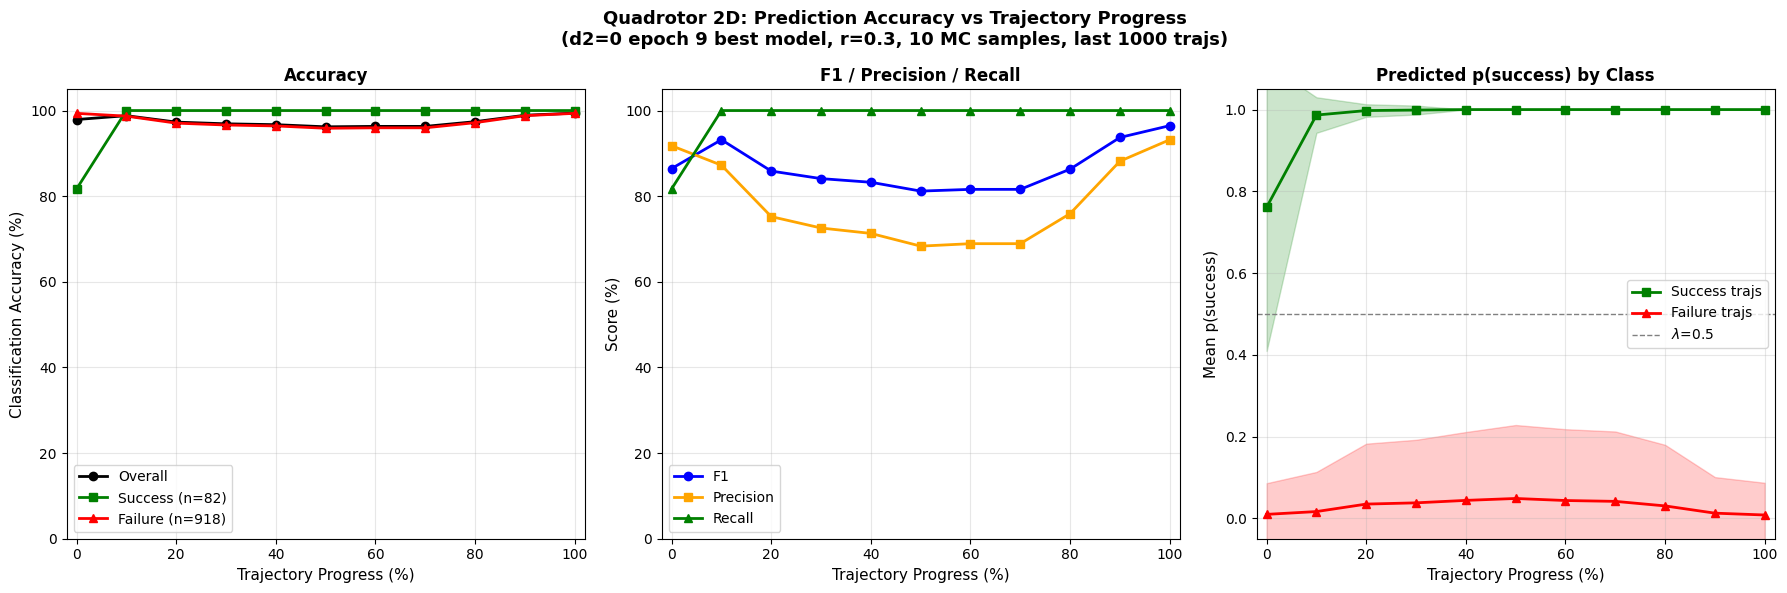

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Quadrotor 2D: Prediction Accuracy vs Trajectory Progress\n"
             f"(d2=0 epoch 9 best model, r={ATTRACTOR_RADIUS}, {NUM_MC_SAMPLES} MC samples, last 1000 trajs)",
             fontsize=13, fontweight='bold')

frac_pct = fractions * 100

# Plot 1: Accuracy
ax = axes[0]
ax.plot(frac_pct, accuracy_all * 100, 'k-o', lw=2, ms=6, label='Overall')
ax.plot(frac_pct, accuracy_succ * 100, 'g-s', lw=2, ms=6, label=f'Success (n={succ_mask.sum()})')
ax.plot(frac_pct, accuracy_fail * 100, 'r-^', lw=2, ms=6, label=f'Failure (n={fail_mask.sum()})')
ax.set_xlabel('Trajectory Progress (%)', fontsize=11)
ax.set_ylabel('Classification Accuracy (%)', fontsize=11)
ax.set_title('Accuracy', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 102)
ax.set_ylim(0, 105)

# Plot 2: F1 / Precision / Recall
ax = axes[1]
ax.plot(frac_pct, f1_per_frac * 100, 'b-o', lw=2, ms=6, label='F1')
ax.plot(frac_pct, prec_per_frac * 100, 'orange', marker='s', lw=2, ms=6, label='Precision')
ax.plot(frac_pct, rec_per_frac * 100, 'g-^', lw=2, ms=6, label='Recall')
ax.set_xlabel('Trajectory Progress (%)', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('F1 / Precision / Recall', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 102)
ax.set_ylim(0, 105)

# Plot 3: Mean p_success by class
ax = axes[2]
mean_p_succ_success = results_p_success[succ_mask].mean(axis=0)
mean_p_succ_failure = results_p_success[fail_mask].mean(axis=0)
std_p_succ_success = results_p_success[succ_mask].std(axis=0)
std_p_succ_failure = results_p_success[fail_mask].std(axis=0)

ax.plot(frac_pct, mean_p_succ_success, 'g-s', lw=2, ms=6, label='Success trajs')
ax.fill_between(frac_pct, mean_p_succ_success - std_p_succ_success,
                mean_p_succ_success + std_p_succ_success, alpha=0.2, color='green')
ax.plot(frac_pct, mean_p_succ_failure, 'r-^', lw=2, ms=6, label='Failure trajs')
ax.fill_between(frac_pct, mean_p_succ_failure - std_p_succ_failure,
                mean_p_succ_failure + std_p_succ_failure, alpha=0.2, color='red')
ax.axhline(y=LAMBDA, color='gray', ls='--', lw=1, label=f'$\\lambda$={LAMBDA}')
ax.set_xlabel('Trajectory Progress (%)', fontsize=11)
ax.set_ylabel('Mean p(success)', fontsize=11)
ax.set_title('Predicted p(success) by Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 102)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('trajectory_accuracy_vs_progress.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Absolute timestep analysis

Since failure trajectories are short (2-78 steps) and success trajectories are long (157-635),
also analyze by absolute timestep (not fraction).

In [14]:
# Analyze at absolute timesteps: 0, 1, 2, 3, 5, 10, 20, 50, 100, 200, 300
abs_steps = [0, 1, 2, 3, 5, 10, 20, 50, 100, 200, 300]

results_abs = np.full((len(trajectories), len(abs_steps)), np.nan)

for step_idx, step in enumerate(abs_steps):
    states = []
    valid_indices = []
    
    for i, traj in enumerate(trajectories):
        if step < len(traj):
            states.append(traj[step])
            valid_indices.append(i)
    
    if len(states) == 0:
        print(f"Step {step}: no trajectories long enough")
        continue
    
    states = np.array(states)
    all_p = []
    for start in range(0, len(states), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(states))
        p_succ, _, _ = predict_from_states(states[start:end], flow_matcher)
        all_p.append(p_succ)
    all_p = np.concatenate(all_p)
    
    for j, i in enumerate(valid_indices):
        results_abs[i, step_idx] = all_p[j]
    
    n_valid = len(valid_indices)
    n_succ_valid = sum(1 for i in valid_indices if traj_labels[i] == 1)
    n_fail_valid = n_valid - n_succ_valid
    print(f"Step {step:>4}: {n_valid} trajs available (S={n_succ_valid}, F={n_fail_valid})")

print("Done!")

Step    0: 1000 trajs available (S=82, F=918)
Step    1: 1000 trajs available (S=82, F=918)
Step    2: 804 trajs available (S=82, F=722)
Step    3: 642 trajs available (S=82, F=560)
Step    5: 513 trajs available (S=82, F=431)
Step   10: 271 trajs available (S=82, F=189)
Step   20: 121 trajs available (S=82, F=39)
Step   50: 86 trajs available (S=82, F=4)
Step  100: 82 trajs available (S=82, F=0)
Step  200: 76 trajs available (S=76, F=0)
Step  300: 52 trajs available (S=52, F=0)
Done!


In [15]:
# Compute metrics by absolute step
print(f"{'Step':>5} {'N':>5} {'N_S':>5} {'N_F':>5} {'Acc':>7} {'Acc(S)':>8} {'Acc(F)':>8} "
      f"{'F1':>7} {'Prec':>7} {'Recall':>7}")
print("-" * 75)

for step_idx, step in enumerate(abs_steps):
    valid = ~np.isnan(results_abs[:, step_idx])
    if valid.sum() == 0:
        continue
    
    p = results_abs[valid, step_idx]
    gt_valid = traj_labels[valid]
    pred = (p > LAMBDA).astype(int)
    
    acc = (pred == gt_valid).mean()
    succ_v = gt_valid == 1
    fail_v = gt_valid == 0
    acc_s = (pred[succ_v] == gt_valid[succ_v]).mean() if succ_v.sum() > 0 else float('nan')
    acc_f = (pred[fail_v] == gt_valid[fail_v]).mean() if fail_v.sum() > 0 else float('nan')
    
    f1 = f1_score(gt_valid, pred, zero_division=0)
    prec = precision_score(gt_valid, pred, zero_division=0)
    rec = recall_score(gt_valid, pred, zero_division=0)
    
    print(f"{step:5d} {valid.sum():5d} {succ_v.sum():5d} {fail_v.sum():5d} "
          f"{acc:7.3f} {acc_s:8.3f} {acc_f:8.3f} {f1:7.3f} {prec:7.3f} {rec:7.3f}")

 Step     N   N_S   N_F     Acc   Acc(S)   Acc(F)      F1    Prec  Recall
---------------------------------------------------------------------------
    0  1000    82   918   0.977    0.793    0.993   0.850   0.915   0.793
    1  1000    82   918   0.958    0.756    0.976   0.747   0.738   0.756
    2   804    82   722   0.943    0.756    0.964   0.729   0.705   0.756
    3   642    82   560   0.924    0.732    0.952   0.710   0.690   0.732
    5   513    82   431   0.916    0.780    0.942   0.749   0.719   0.780
   10   271    82   189   0.967    0.915    0.989   0.943   0.974   0.915
   20   121    82    39   0.926    0.927    0.923   0.944   0.962   0.927
   50    86    82     4   1.000    1.000    1.000   1.000   1.000   1.000
  100    82    82     0   1.000    1.000      nan   1.000   1.000   1.000
  200    76    76     0   1.000    1.000      nan   1.000   1.000   1.000
  300    52    52     0   1.000    1.000      nan   1.000   1.000   1.000


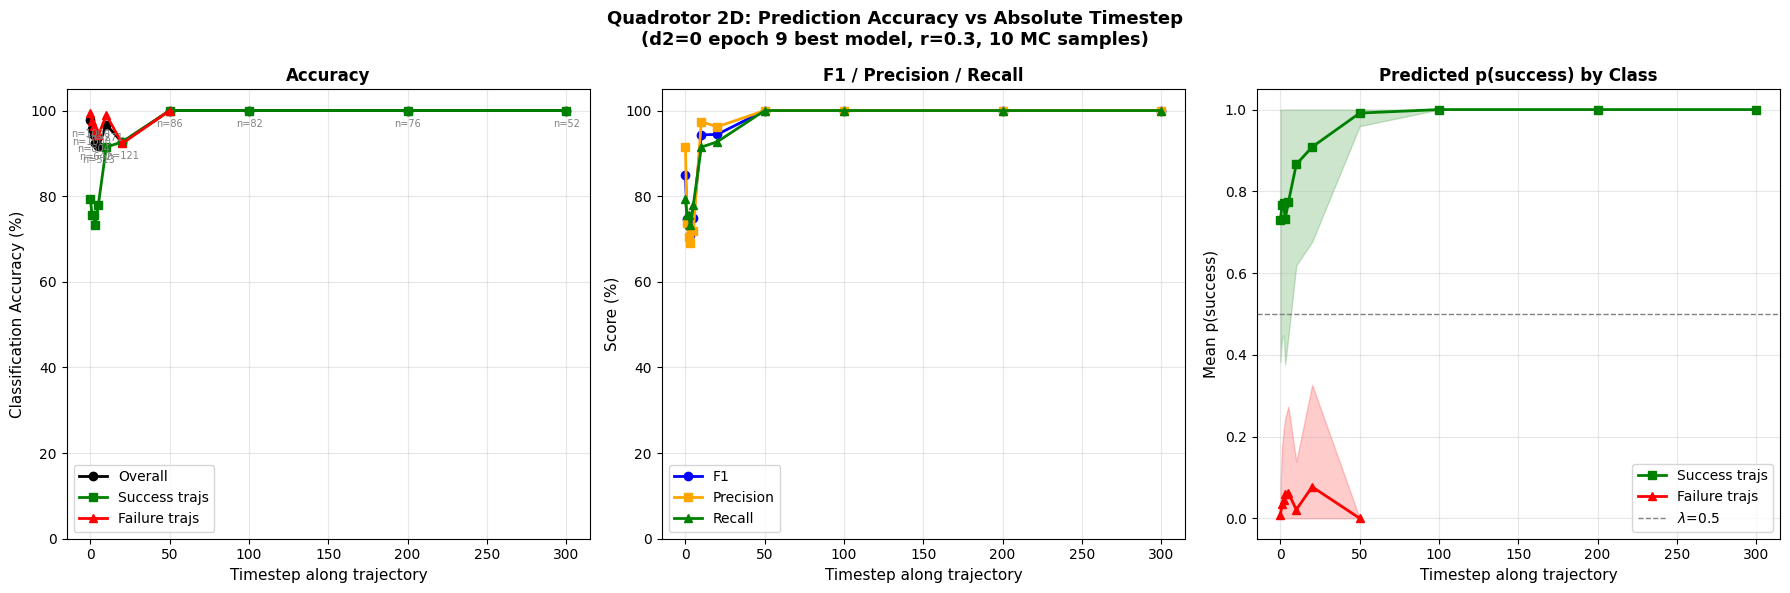

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Quadrotor 2D: Prediction Accuracy vs Absolute Timestep\n"
             f"(d2=0 epoch 9 best model, r={ATTRACTOR_RADIUS}, {NUM_MC_SAMPLES} MC samples)",
             fontsize=13, fontweight='bold')

# Compute per-step metrics
acc_all_abs, acc_s_abs, acc_f_abs = [], [], []
f1_abs, prec_abs, rec_abs = [], [], []
mean_p_s_abs, mean_p_f_abs, std_p_s_abs, std_p_f_abs = [], [], [], []
valid_steps = []
n_available = []

for step_idx, step in enumerate(abs_steps):
    valid = ~np.isnan(results_abs[:, step_idx])
    if valid.sum() < 10:
        continue
    valid_steps.append(step)
    n_available.append(valid.sum())
    
    p = results_abs[valid, step_idx]
    gt_v = traj_labels[valid]
    pred = (p > LAMBDA).astype(int)
    
    acc_all_abs.append((pred == gt_v).mean())
    sm = gt_v == 1
    fm = gt_v == 0
    acc_s_abs.append((pred[sm] == gt_v[sm]).mean() if sm.sum() > 0 else np.nan)
    acc_f_abs.append((pred[fm] == gt_v[fm]).mean() if fm.sum() > 0 else np.nan)
    f1_abs.append(f1_score(gt_v, pred, zero_division=0))
    prec_abs.append(precision_score(gt_v, pred, zero_division=0))
    rec_abs.append(recall_score(gt_v, pred, zero_division=0))
    mean_p_s_abs.append(p[sm].mean() if sm.sum() > 0 else np.nan)
    mean_p_f_abs.append(p[fm].mean() if fm.sum() > 0 else np.nan)
    std_p_s_abs.append(p[sm].std() if sm.sum() > 0 else np.nan)
    std_p_f_abs.append(p[fm].std() if fm.sum() > 0 else np.nan)

vs = np.array(valid_steps)

# Plot 1: Accuracy
ax = axes[0]
ax.plot(vs, np.array(acc_all_abs)*100, 'k-o', lw=2, ms=6, label='Overall')
ax.plot(vs, np.array(acc_s_abs)*100, 'g-s', lw=2, ms=6, label='Success trajs')
ax.plot(vs, np.array(acc_f_abs)*100, 'r-^', lw=2, ms=6, label='Failure trajs')
ax.set_xlabel('Timestep along trajectory', fontsize=11)
ax.set_ylabel('Classification Accuracy (%)', fontsize=11)
ax.set_title('Accuracy', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
# Add sample counts as secondary info
for i, (s, n) in enumerate(zip(valid_steps, n_available)):
    ax.annotate(f'n={n}', (s, acc_all_abs[i]*100), fontsize=7,
                textcoords='offset points', xytext=(0, -12), ha='center', color='gray')

# Plot 2: F1/P/R
ax = axes[1]
ax.plot(vs, np.array(f1_abs)*100, 'b-o', lw=2, ms=6, label='F1')
ax.plot(vs, np.array(prec_abs)*100, color='orange', marker='s', lw=2, ms=6, label='Precision')
ax.plot(vs, np.array(rec_abs)*100, 'g-^', lw=2, ms=6, label='Recall')
ax.set_xlabel('Timestep along trajectory', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('F1 / Precision / Recall', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

# Plot 3: Mean p_success by class
ax = axes[2]
mp_s = np.array(mean_p_s_abs)
mp_f = np.array(mean_p_f_abs)
sp_s = np.array(std_p_s_abs)
sp_f = np.array(std_p_f_abs)
ax.plot(vs, mp_s, 'g-s', lw=2, ms=6, label='Success trajs')
ax.fill_between(vs, mp_s - sp_s, np.minimum(mp_s + sp_s, 1.0), alpha=0.2, color='green')
ax.plot(vs, mp_f, 'r-^', lw=2, ms=6, label='Failure trajs')
ax.fill_between(vs, np.maximum(mp_f - sp_f, 0.0), mp_f + sp_f, alpha=0.2, color='red')
ax.axhline(y=LAMBDA, color='gray', ls='--', lw=1, label=f'$\\lambda$={LAMBDA}')
ax.set_xlabel('Timestep along trajectory', fontsize=11)
ax.set_ylabel('Mean p(success)', fontsize=11)
ax.set_title('Predicted p(success) by Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('trajectory_accuracy_vs_timestep.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-trajectory heatmap: p(success) evolution

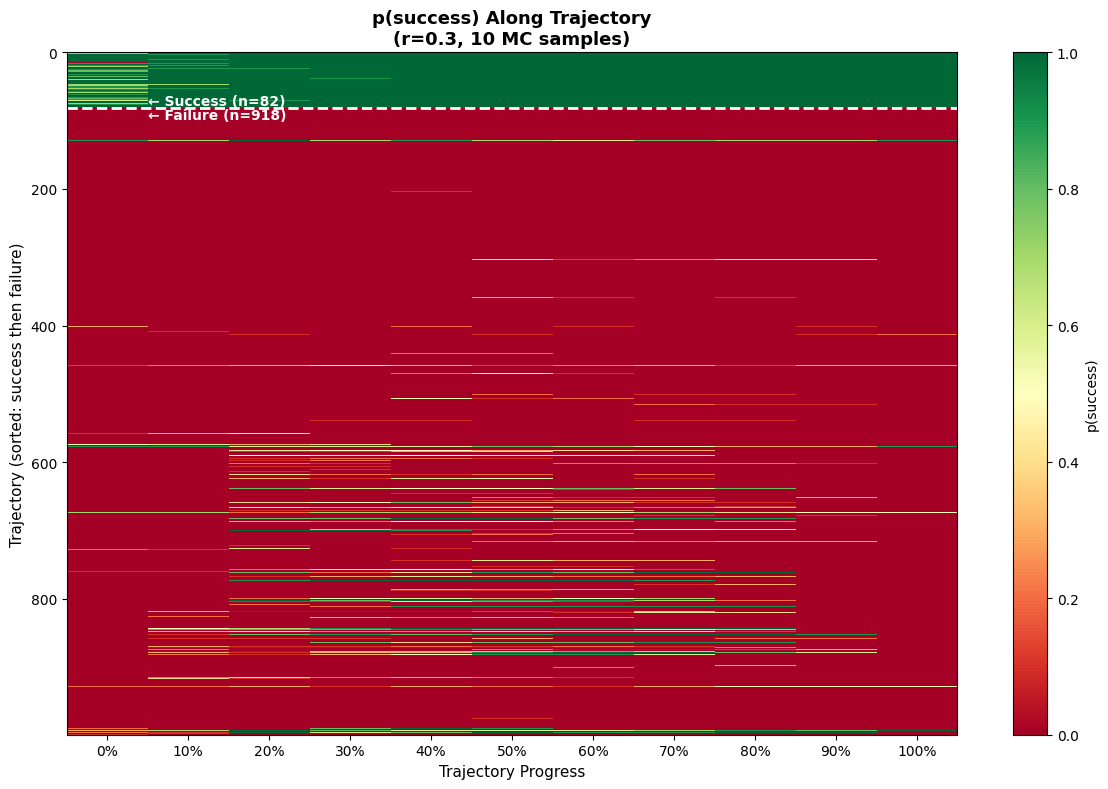

In [17]:
# Sort trajectories: success first (sorted by length), then failure (sorted by length)
succ_idx = np.where(traj_labels == 1)[0]
fail_idx = np.where(traj_labels == 0)[0]
succ_sorted = succ_idx[np.argsort(traj_lengths[succ_idx])]
fail_sorted = fail_idx[np.argsort(traj_lengths[fail_idx])]
sorted_order = np.concatenate([succ_sorted, fail_sorted])

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(results_p_success[sorted_order], aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(fractions)))
ax.set_xticklabels([f'{f:.0%}' for f in fractions])
ax.set_xlabel('Trajectory Progress', fontsize=11)
ax.set_ylabel('Trajectory (sorted: success then failure)', fontsize=11)
ax.axhline(y=len(succ_sorted) - 0.5, color='white', lw=2, ls='--')
ax.text(0.5, len(succ_sorted) - 5, f'← Success (n={len(succ_sorted)})', 
        color='white', fontsize=10, fontweight='bold')
ax.text(0.5, len(succ_sorted) + 15, f'← Failure (n={len(fail_sorted)})', 
        color='white', fontsize=10, fontweight='bold')
ax.set_title(f'p(success) Along Trajectory\n(r={ATTRACTOR_RADIUS}, {NUM_MC_SAMPLES} MC samples)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='p(success)')
plt.tight_layout()
plt.savefig('trajectory_psuccess_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Time-to-correct-prediction analysis

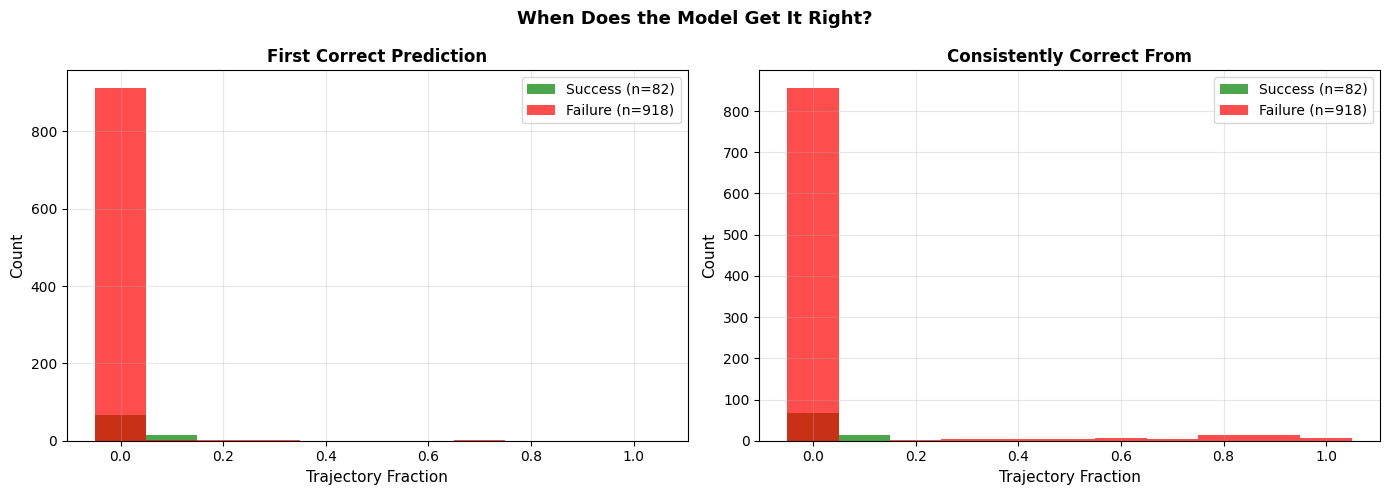


Always-correct-from fraction stats:
  Success: mean=0.02, median=0.00, at_start=67, never_correct=0, total=82
  Failure: mean=0.04, median=0.00, at_start=856, never_correct=6, total=918


In [18]:
# For each trajectory, find the earliest fraction at which the model's prediction
# becomes correct AND stays correct for all subsequent fractions

earliest_correct_frac = np.full(len(trajectories), np.nan)
always_correct_from_frac = np.full(len(trajectories), np.nan)

for i in range(len(trajectories)):
    preds_i = (results_p_success[i] > LAMBDA).astype(int)
    correct_i = (preds_i == traj_labels[i])
    
    # Earliest correct
    correct_idxs = np.where(correct_i)[0]
    if len(correct_idxs) > 0:
        earliest_correct_frac[i] = fractions[correct_idxs[0]]
    
    # Earliest fraction from which it's ALWAYS correct thereafter
    for j in range(len(fractions)):
        if correct_i[j:].all():
            always_correct_from_frac[i] = fractions[j]
            break

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('When Does the Model Get It Right?', fontsize=13, fontweight='bold')

for ax, data, title in [
    (axes[0], earliest_correct_frac, 'First Correct Prediction'),
    (axes[1], always_correct_from_frac, 'Consistently Correct From'),
]:
    bins = np.arange(-0.05, 1.15, 0.1)
    ax.hist(data[succ_mask], bins=bins, alpha=0.7, label=f'Success (n={succ_mask.sum()})', color='green')
    ax.hist(data[fail_mask], bins=bins, alpha=0.7, label=f'Failure (n={fail_mask.sum()})', color='red')
    ax.set_xlabel('Trajectory Fraction', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trajectory_time_to_correct.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("\nAlways-correct-from fraction stats:")
for label, mask in [("Success", succ_mask), ("Failure", fail_mask)]:
    vals = always_correct_from_frac[mask]
    valid = vals[~np.isnan(vals)]
    never = np.isnan(vals).sum()
    print(f"  {label}: mean={valid.mean():.2f}, median={np.median(valid):.2f}, "
          f"at_start={( valid == 0).sum()}, never_correct={never}, total={len(vals)}")

## 10. When does the model become correct along success trajectories?

For each success trajectory, walk through every state and predict using the **actual pipeline logic**:
- Three-way MC classification via `system.classify_attractor` (success/failure/invalid)
- Two-sided decision rule (λ=0.5, δ=0.05):
  - **SUCCESS**: p_success > 0.55 and not invalid
  - **FAILURE**: (1-p_failure) < 0.45 and not invalid
  - **INVALID**: p_invalid >= 0.45
  - **UNCERTAIN**: everything else

In [19]:
LAMBDA_STAR = 0.5
DELTA = 0.05

succ_indices = np.where(traj_labels == 1)[0]
print(f"Evaluating {len(succ_indices)} success trajectories state-by-state...")
print(f"Decision rule: two_sided (λ={LAMBDA_STAR}, δ={DELTA})")
print(f"  SUCCESS:   p_success > {LAMBDA_STAR + DELTA}")
print(f"  FAILURE:   (1-p_failure) < {LAMBDA_STAR - DELTA}")
print(f"  INVALID:   p_invalid >= {LAMBDA_STAR - DELTA}")
print(f"  UNCERTAIN: otherwise\n")

per_traj = []

for idx in tqdm(succ_indices, desc="Success trajectories"):
    traj = trajectories[idx]
    T = len(traj)
    
    # Predict from every state, get three-way probabilities
    all_ps, all_pf, all_pi = [], [], []
    for start in range(0, T, BATCH_SIZE):
        end = min(start + BATCH_SIZE, T)
        ps, pf, pi = predict_from_states(traj[start:end], flow_matcher)
        all_ps.append(ps)
        all_pf.append(pf)
        all_pi.append(pi)
    
    p_success = np.concatenate(all_ps)
    p_failure = np.concatenate(all_pf)
    p_invalid = np.concatenate(all_pi)
    
    # Apply two-sided decision rule
    pred = classify_two_sided(p_success, p_failure, p_invalid, LAMBDA_STAR, DELTA)
    
    # pred:  1=success, 0=failure, -2=invalid, -1=uncertain
    is_correct = (pred == 1)        # correctly predicted success
    is_wrong = (pred == 0)          # confidently wrong (predicted failure)
    is_invalid = (pred == -2)       # separatrix/invalid
    is_uncertain = (pred == -1)     # uncertain
    
    # When does the model first correctly predict success?
    correct_idx = np.where(is_correct)[0]
    first_correct_step = int(correct_idx[0]) if len(correct_idx) > 0 else None
    
    # When does it STAY correct (pred=1) for all remaining states?
    stay_correct_step = None
    for s in range(T):
        if is_correct[s:].all():
            stay_correct_step = s
            break
    
    per_traj.append({
        "idx": idx, "length": T,
        "p_success": p_success, "p_failure": p_failure, "p_invalid": p_invalid,
        "pred": pred,
        "first_correct_step": first_correct_step,
        "first_correct_frac": first_correct_step / (T - 1) if first_correct_step is not None else None,
        "stay_correct_step": stay_correct_step,
        "stay_correct_frac": stay_correct_step / (T - 1) if stay_correct_step is not None else None,
        "pct_correct": is_correct.sum() / T * 100,
        "pct_wrong": is_wrong.sum() / T * 100,
        "pct_invalid": is_invalid.sum() / T * 100,
        "pct_uncertain": is_uncertain.sum() / T * 100,
    })

print("Done!\n")

# ── Summary ──
first_steps = np.array([r["first_correct_step"] for r in per_traj if r["first_correct_step"] is not None])
first_fracs = np.array([r["first_correct_frac"] for r in per_traj if r["first_correct_frac"] is not None])
stay_steps = np.array([r["stay_correct_step"] for r in per_traj if r["stay_correct_step"] is not None])
stay_fracs = np.array([r["stay_correct_frac"] for r in per_traj if r["stay_correct_frac"] is not None])
never_correct = sum(1 for r in per_traj if r["first_correct_step"] is None)
never_stays = sum(1 for r in per_traj if r["stay_correct_step"] is None)

print(f"First confident success prediction:")
print(f"  Achieved by: {len(first_steps)}/{len(per_traj)} trajectories ({never_correct} never)")
if len(first_steps) > 0:
    print(f"  Timestep:  mean={first_steps.mean():.0f}, median={np.median(first_steps):.0f}, "
          f"min={first_steps.min()}, max={first_steps.max()}")
    print(f"  Fraction:  mean={first_fracs.mean():.2f}, median={np.median(first_fracs):.2f}")

print(f"\nStays correct permanently:")
print(f"  Achieved by: {len(stay_steps)}/{len(per_traj)} trajectories ({never_stays} never lock in)")
if len(stay_steps) > 0:
    print(f"  Timestep:  mean={stay_steps.mean():.0f}, median={np.median(stay_steps):.0f}, "
          f"min={stay_steps.min()}, max={stay_steps.max()}")
    print(f"  Fraction:  mean={stay_fracs.mean():.2f}, median={np.median(stay_fracs):.2f}")

print(f"\nAverage trajectory phase breakdown:")
print(f"  Correct   (pred=SUCCESS):   {np.mean([r['pct_correct'] for r in per_traj]):.1f}%")
print(f"  Wrong     (pred=FAILURE):   {np.mean([r['pct_wrong'] for r in per_traj]):.1f}%")
print(f"  Invalid   (pred=INVALID):   {np.mean([r['pct_invalid'] for r in per_traj]):.1f}%")
print(f"  Uncertain (pred=UNCERTAIN): {np.mean([r['pct_uncertain'] for r in per_traj]):.1f}%")

Evaluating 82 success trajectories state-by-state...
Decision rule: two_sided (λ=0.5, δ=0.05)
  SUCCESS:   p_success > 0.55
  FAILURE:   (1-p_failure) < 0.45
  INVALID:   p_invalid >= 0.45
  UNCERTAIN: otherwise



Success trajectories: 100%|██████████| 82/82 [00:48<00:00,  1.68it/s]

Done!

First confident success prediction:
  Achieved by: 82/82 trajectories (0 never)
  Timestep:  mean=2, median=0, min=0, max=39
  Fraction:  mean=0.01, median=0.00

Stays correct permanently:
  Achieved by: 82/82 trajectories (0 never lock in)
  Timestep:  mean=6, median=2, min=0, max=39
  Fraction:  mean=0.02, median=0.01

Average trajectory phase breakdown:
  Correct   (pred=SUCCESS):   99.0%
  Wrong     (pred=FAILURE):   0.5%
  Invalid   (pred=INVALID):   0.3%
  Uncertain (pred=UNCERTAIN): 0.2%


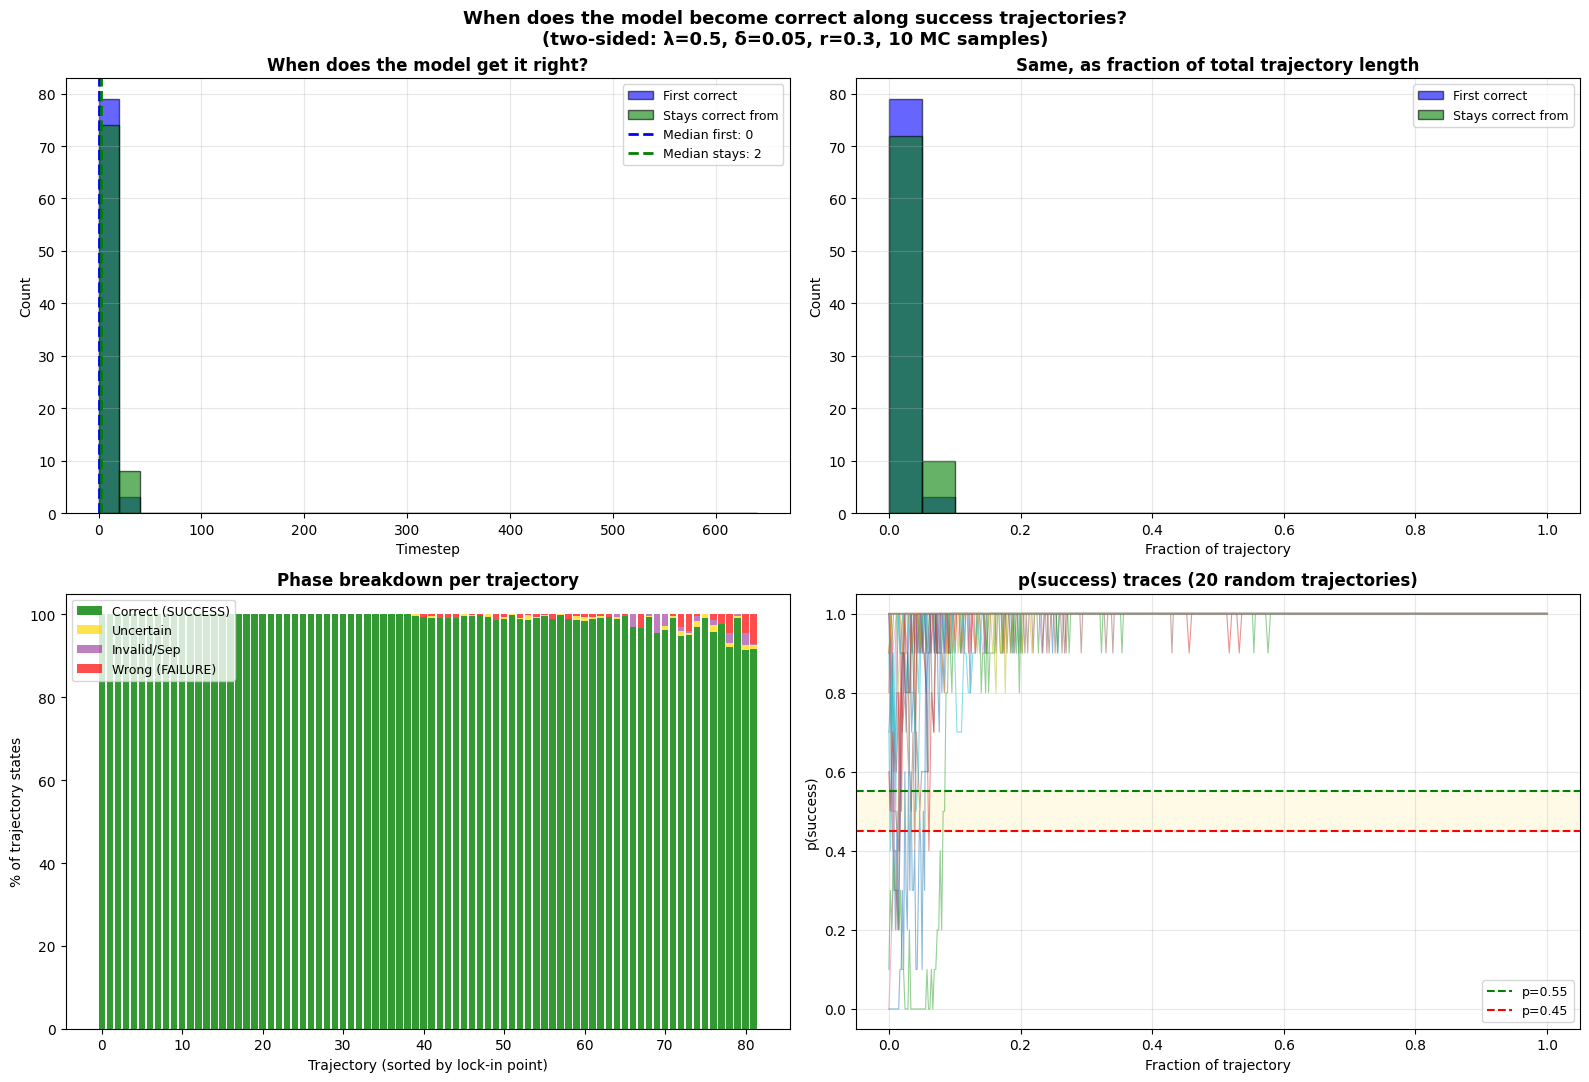

In [22]:
SUCCESS_THRESH = LAMBDA_STAR + DELTA   # 0.55
FAILURE_THRESH = LAMBDA_STAR - DELTA   # 0.45

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f"When does the model become correct along success trajectories?\n"
             f"(two-sided: λ={LAMBDA_STAR}, δ={DELTA}, "
             f"r={ATTRACTOR_RADIUS}, {NUM_MC_SAMPLES} MC samples)",
             fontsize=13, fontweight='bold')

# 1: Histogram of "first correct step" and "stays correct from step"
ax = axes[0, 0]
bins = np.arange(0, max(r["length"] for r in per_traj) + 20, 20)
ax.hist(first_steps, bins=bins, alpha=0.6, color='blue', label='First correct', edgecolor='black', lw=0.5)
ax.hist(stay_steps, bins=bins, alpha=0.6, color='green', label='Stays correct from', edgecolor='black', lw=0.5)
ax.axvline(np.median(first_steps), color='blue', ls='--', lw=2, label=f'Median first: {np.median(first_steps):.0f}')
if len(stay_steps) > 0:
    ax.axvline(np.median(stay_steps), color='green', ls='--', lw=2, label=f'Median stays: {np.median(stay_steps):.0f}')
ax.set_xlabel('Timestep')
ax.set_ylabel('Count')
ax.set_title('When does the model get it right?', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2: Same but as fraction of trajectory
ax = axes[0, 1]
bins_frac = np.arange(0, 1.05, 0.05)
ax.hist(first_fracs, bins=bins_frac, alpha=0.6, color='blue', label='First correct', edgecolor='black', lw=0.5)
if len(stay_fracs) > 0:
    ax.hist(stay_fracs, bins=bins_frac, alpha=0.6, color='green', label='Stays correct from', edgecolor='black', lw=0.5)
ax.set_xlabel('Fraction of trajectory')
ax.set_ylabel('Count')
ax.set_title('Same, as fraction of total trajectory length', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3: Per-trajectory phase breakdown (sorted by "stays correct" step)
ax = axes[1, 0]
sorted_traj = sorted(per_traj, key=lambda r: r["stay_correct_frac"] if r["stay_correct_frac"] is not None else 2.0)
pct_c_arr = [r["pct_correct"] for r in sorted_traj]
pct_w_arr = [r["pct_wrong"] for r in sorted_traj]
pct_i_arr = [r["pct_invalid"] for r in sorted_traj]
pct_u_arr = [r["pct_uncertain"] for r in sorted_traj]
x = np.arange(len(sorted_traj))
ax.bar(x, pct_c_arr, color='green', alpha=0.8, label='Correct (SUCCESS)')
bottom = np.array(pct_c_arr)
ax.bar(x, pct_u_arr, bottom=bottom, color='gold', alpha=0.7, label='Uncertain')
bottom = bottom + np.array(pct_u_arr)
ax.bar(x, pct_i_arr, bottom=bottom, color='purple', alpha=0.5, label='Invalid/Sep')
bottom = bottom + np.array(pct_i_arr)
ax.bar(x, pct_w_arr, bottom=bottom, color='red', alpha=0.7, label='Wrong (FAILURE)')
ax.set_xlabel('Trajectory (sorted by lock-in point)')
ax.set_ylabel('% of trajectory states')
ax.set_title('Phase breakdown per trajectory', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(0, 105)

# 4: Sample p(success) traces
ax = axes[1, 1]
np.random.seed(42)
sample_idx = np.random.choice(len(per_traj), size=min(20, len(per_traj)), replace=False)
for si in sample_idx:
    r = per_traj[si]
    frac = np.linspace(0, 1, r["length"])
    ax.plot(frac, r["p_success"], alpha=0.5, lw=0.8)
ax.axhline(y=SUCCESS_THRESH, color='green', ls='--', lw=1.5, label=f'p={SUCCESS_THRESH}')
ax.axhline(y=FAILURE_THRESH, color='red', ls='--', lw=1.5, label=f'p={FAILURE_THRESH}')
ax.axhspan(FAILURE_THRESH, SUCCESS_THRESH, alpha=0.1, color='gold')
ax.set_xlabel('Fraction of trajectory')
ax.set_ylabel('p(success)')
ax.set_title('p(success) traces (20 random trajectories)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('success_traj_perstate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# <cell_type>markdown</cell_type>## 11. Success rate at each absolute timestep (success trajectories)

# For each timestep t=0,1,2,..., across all success trajectories that are still alive at step t:
# what fraction does the model confidently predict as SUCCESS?

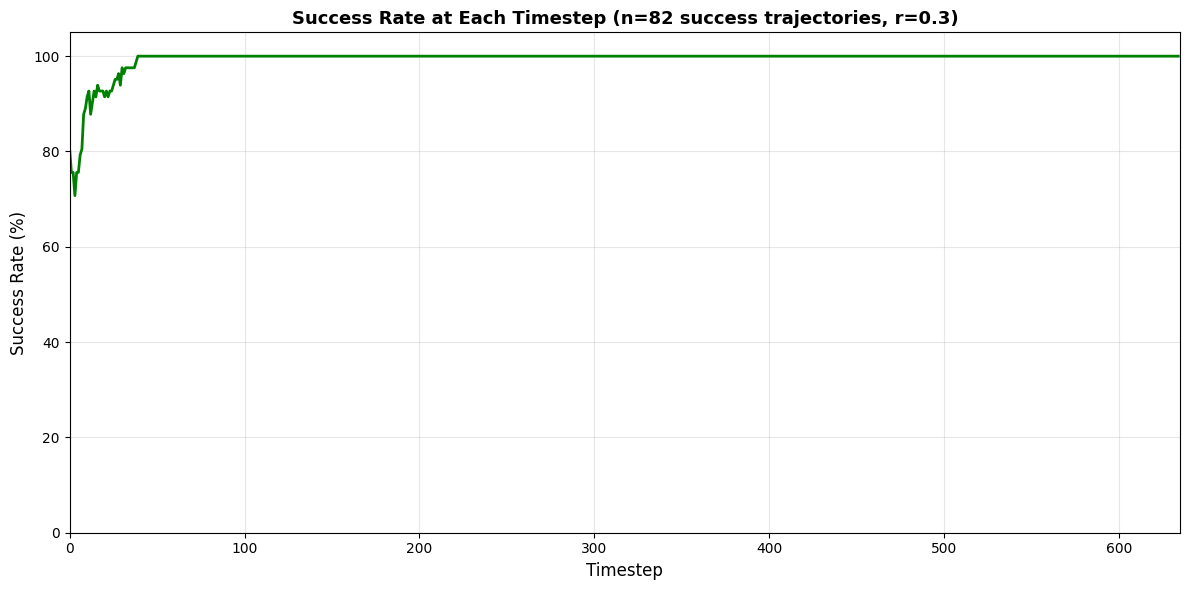

In [24]:
# Find max trajectory length across success trajectories
max_len = max(r["length"] for r in per_traj)

n_alive = np.zeros(max_len, dtype=int)
n_success = np.zeros(max_len, dtype=int)

for r in per_traj:
    T = r["length"]
    pred = r["pred"]
    n_alive[:T] += 1
    n_success[:T] += (pred == 1)

valid_mask = n_alive > 0
timesteps = np.arange(max_len)[valid_mask]
success_rate = n_success[valid_mask] / n_alive[valid_mask] * 100
alive = n_alive[valid_mask]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(timesteps, success_rate, 'g-', lw=2)
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title(f'Success Rate at Each Timestep (n={len(per_traj)} success trajectories, r={ATTRACTOR_RADIUS})',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max_len)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('success_rate_per_timestep.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Failure rate at each absolute timestep (failure trajectories)

Same analysis but for failure trajectories: at each timestep, what fraction does the model correctly predict as FAILURE?

In [37]:
# Run per-state predictions for all failure trajectories
fail_indices = np.where(traj_labels == 0)[0]
print(f"Evaluating {len(fail_indices)} failure trajectories state-by-state...")

per_traj_fail = []

for idx in tqdm(fail_indices, desc="Failure trajectories"):
    traj = trajectories[idx]
    T = len(traj)
    
    all_ps, all_pf, all_pi = [], [], []
    for start in range(0, T, BATCH_SIZE):
        end = min(start + BATCH_SIZE, T)
        ps, pf, pi = predict_from_states(traj[start:end], flow_matcher)
        all_ps.append(ps)
        all_pf.append(pf)
        all_pi.append(pi)
    
    p_success = np.concatenate(all_ps)
    p_failure = np.concatenate(all_pf)
    p_invalid = np.concatenate(all_pi)
    
    pred = classify_two_sided(p_success, p_failure, p_invalid, LAMBDA_STAR, DELTA)
    
    per_traj_fail.append({"idx": idx, "length": T, "pred": pred})
    
    # if idx == 100:
    #     break

print("Done!")



Evaluating 918 failure trajectories state-by-state...


Failure trajectories: 100%|██████████| 918/918 [07:55<00:00,  1.93it/s]

Done!


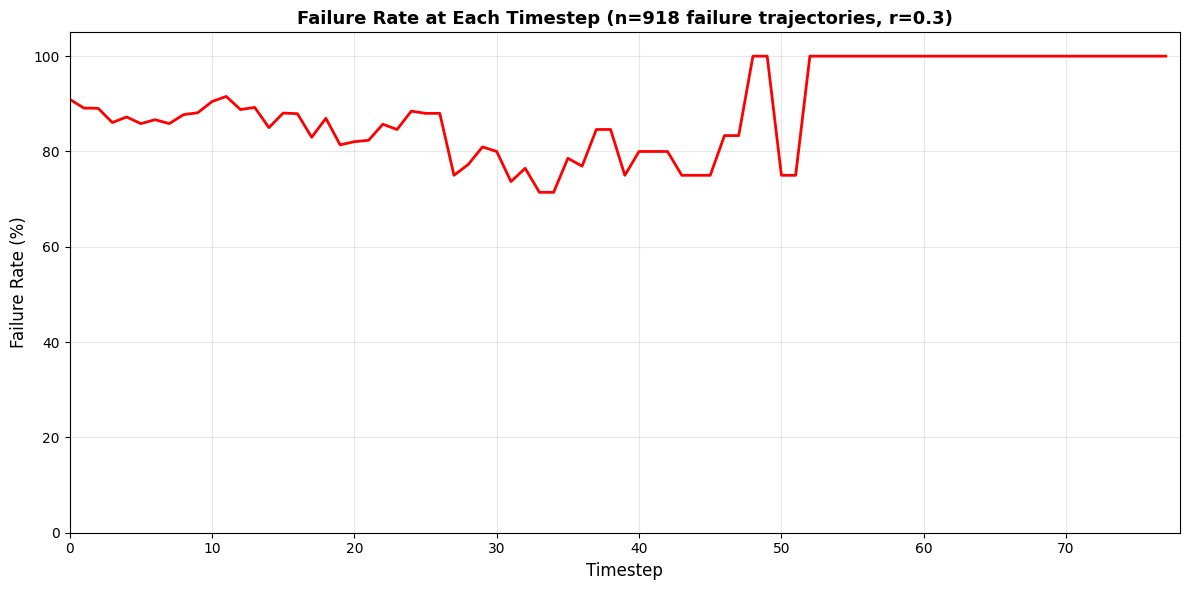


Failure trajectories: max length = 78 steps
 Step  Alive  Correct%
-------------------------
    0    918      91.0
    1    918      89.1
    2    722      89.1
    3    560      86.1
    5    431      85.8
   10    189      90.5
   20     39      82.1
   50      4      75.0
   60      2     100.0
   70      1     100.0


In [45]:
# Compute failure rate (correct prediction) at each timestep
max_len_fail = max(r["length"] for r in per_traj_fail)

n_alive_f = np.zeros(max_len_fail, dtype=int)
n_correct_f = np.zeros(max_len_fail, dtype=int)  # pred == 0 (FAILURE) is correct

for r in per_traj_fail:
    T = r["length"]
    pred = r["pred"]
    n_alive_f[:T] += 1
    n_correct_f[:T] += (pred == 0)

valid_mask_f = n_alive_f > 0
timesteps_f = np.arange(max_len_fail)[valid_mask_f]
failure_correct_rate = n_correct_f[valid_mask_f] / n_alive_f[valid_mask_f] * 100
alive_f = n_alive_f[valid_mask_f]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(timesteps_f, failure_correct_rate, 'r-', lw=2)
ax.set_xlabel('Timestep', fontsize=12)
ax.set_ylabel('Failure Rate (%)', fontsize=12)
ax.set_title(f'Failure Rate at Each Timestep (n={len(per_traj_fail)} failure trajectories, r={ATTRACTOR_RADIUS})',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max_len_fail)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('failure_rate_per_timestep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFailure trajectories: max length = {max_len_fail} steps")
print(f"{'Step':>5} {'Alive':>6} {'Correct%':>9}")
print("-" * 25)
for t in [0, 1, 2, 3, 5, 10, 20, 50, 60, 70]:
    if t < len(timesteps_f):
        print(f"{t:5d} {alive_f[t]:6d} {failure_correct_rate[t]:9.1f}")

In [46]:
from scipy.spatial.distance import cdist

# Gather initial states (t=0) for success and failure
succ_init = np.array([trajectories[i][0] for i in range(len(trajectories)) if traj_labels[i] == 1])
fail_init = np.array([trajectories[i][0] for i in range(len(trajectories)) if traj_labels[i] == 0])

print(f"Success initial states: {succ_init.shape}")
print(f"Failure initial states: {fail_init.shape}")

# Distance from each success initial state to nearest failure initial state
dist_sf = cdist(succ_init, fail_init)  # [82, 918]
nn_dist_succ_to_fail = dist_sf.min(axis=1)  # [82]

# Distance from each failure initial state to nearest success initial state
nn_dist_fail_to_succ = dist_sf.min(axis=0)  # [918]

# Identify which success trajectories were misclassified at t=0
# Use the per_traj data from Section 10
misclassified_mask = np.array([r["pred"][0] != 1 for r in per_traj])  # not predicted SUCCESS at t=0
correct_mask = ~misclassified_mask

print(f"\nAt t=0: {correct_mask.sum()} correctly predicted, {misclassified_mask.sum()} misclassified")

print(f"\nNearest failure neighbor distance (success states):")
print(f"  All success:      mean={nn_dist_succ_to_fail.mean():.4f}, "
      f"median={np.median(nn_dist_succ_to_fail):.4f}, "
      f"min={nn_dist_succ_to_fail.min():.4f}, max={nn_dist_succ_to_fail.max():.4f}")
print(f"  Correct at t=0:   mean={nn_dist_succ_to_fail[correct_mask].mean():.4f}, "
      f"median={np.median(nn_dist_succ_to_fail[correct_mask]):.4f}")
print(f"  Misclass at t=0:  mean={nn_dist_succ_to_fail[misclassified_mask].mean():.4f}, "
      f"median={np.median(nn_dist_succ_to_fail[misclassified_mask]):.4f}")

# How many failure neighbors within various radii for each success state
for radius in [0.05, 0.1, 0.2, 0.5]:
    n_fail_within = (dist_sf < radius).sum(axis=1)  # [82]
    print(f"\n  Failure neighbors within r={radius}:")
    print(f"    Correct:  mean={n_fail_within[correct_mask].mean():.1f}, "
          f"median={np.median(n_fail_within[correct_mask]):.0f}")
    print(f"    Misclass: mean={n_fail_within[misclassified_mask].mean():.1f}, "
          f"median={np.median(n_fail_within[misclassified_mask]):.0f}")

Success initial states: (82, 6)
Failure initial states: (918, 6)

At t=0: 66 correctly predicted, 16 misclassified

Nearest failure neighbor distance (success states):
  All success:      mean=0.9449, median=0.9519, min=0.4579, max=1.3575
  Correct at t=0:   mean=0.9490, median=0.9519
  Misclass at t=0:  mean=0.9281, median=0.9546

  Failure neighbors within r=0.05:
    Correct:  mean=0.0, median=0
    Misclass: mean=0.0, median=0

  Failure neighbors within r=0.1:
    Correct:  mean=0.0, median=0
    Misclass: mean=0.0, median=0

  Failure neighbors within r=0.2:
    Correct:  mean=0.0, median=0
    Misclass: mean=0.0, median=0

  Failure neighbors within r=0.5:
    Correct:  mean=0.0, median=0
    Misclass: mean=0.0, median=0


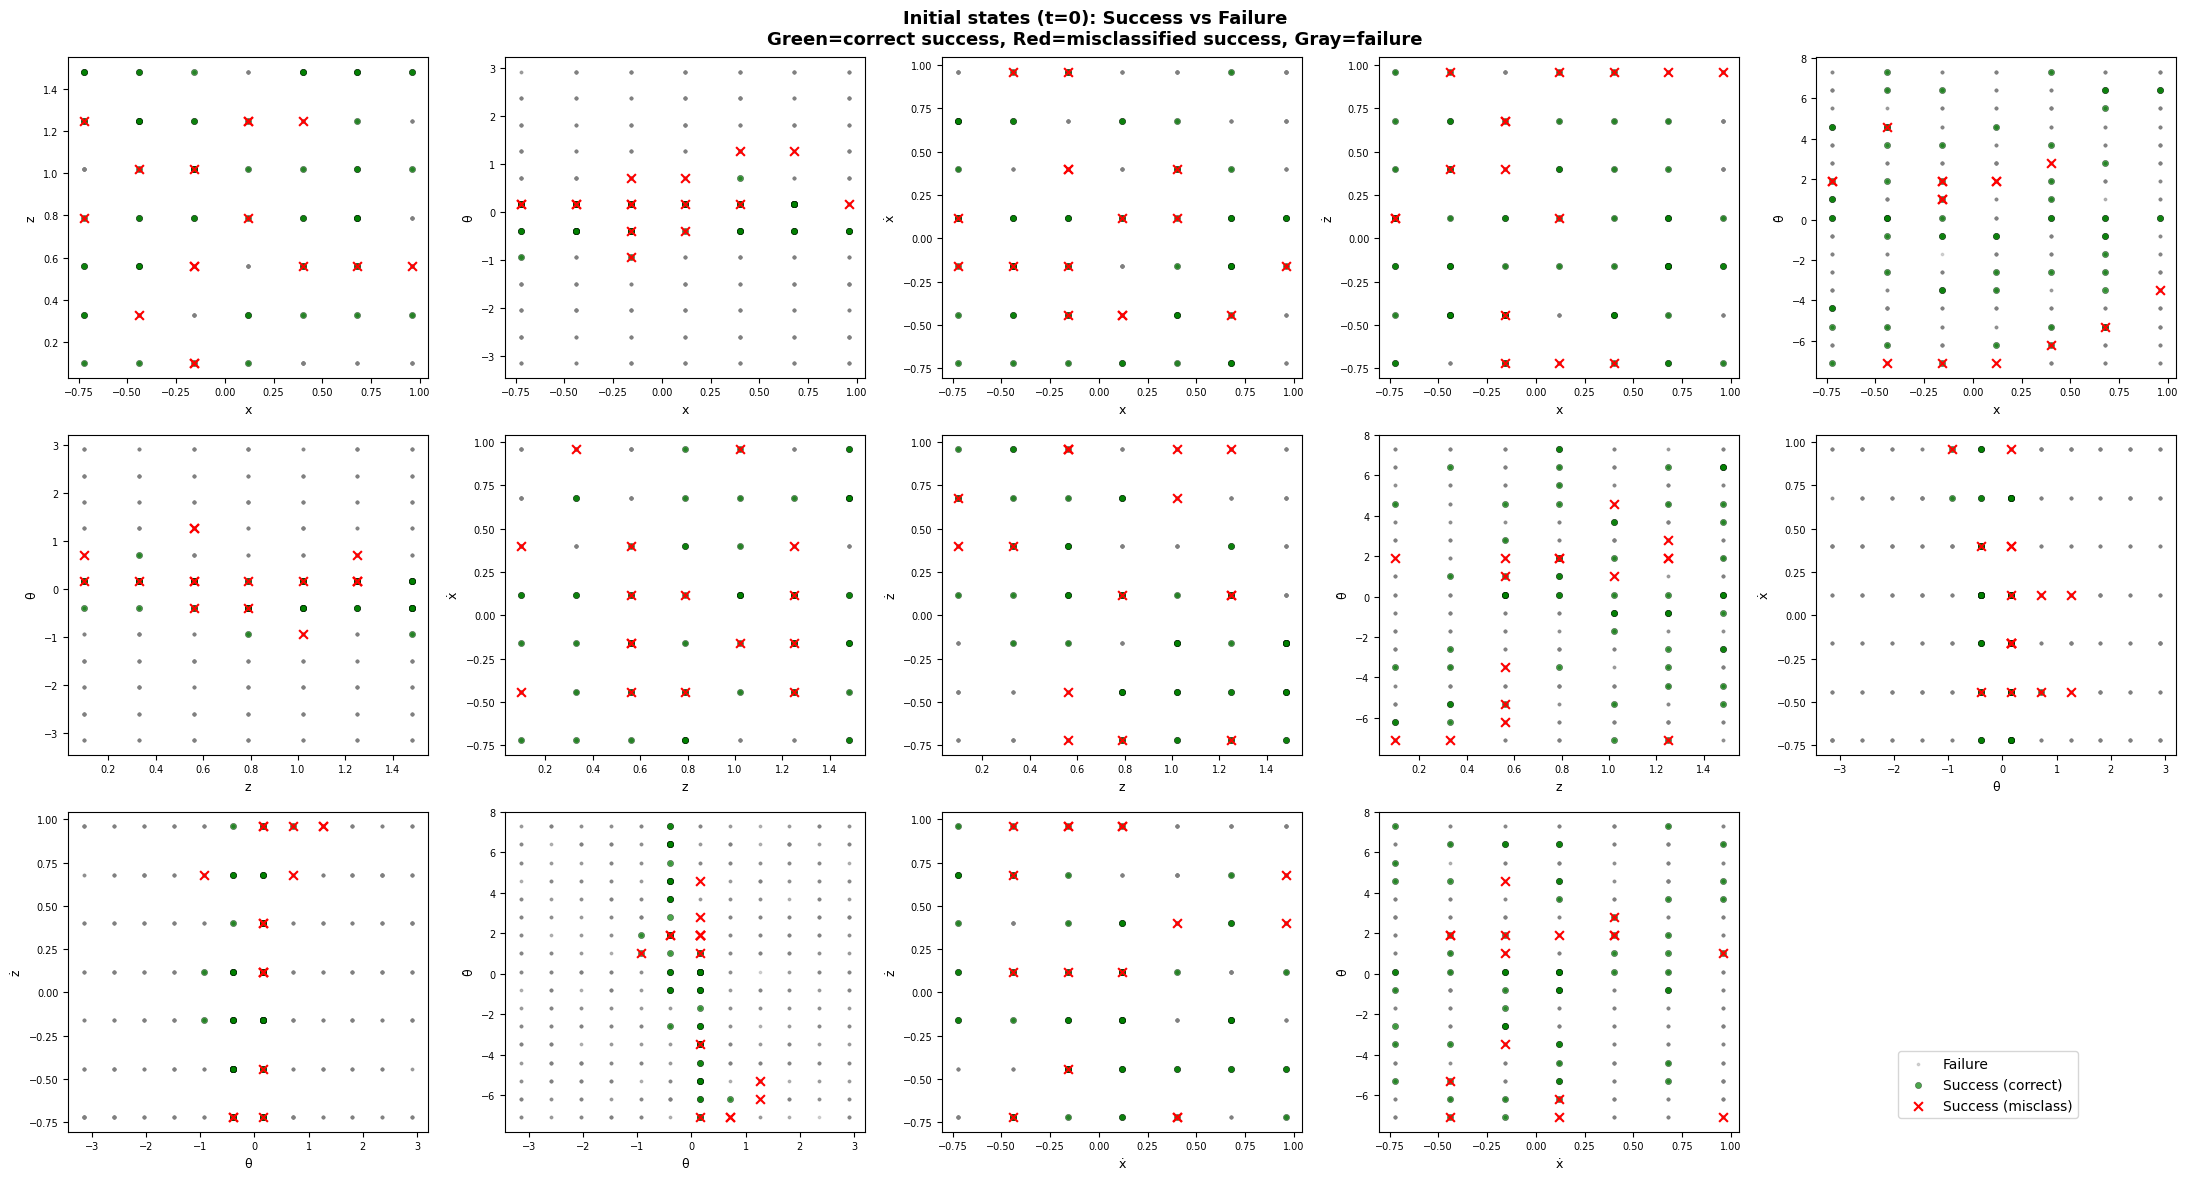

In [47]:
dim_names = ['x', 'z', 'θ', 'ẋ', 'ż', 'θ̇']

# Pairwise 2D projections: plot success vs failure initial states
# Highlight misclassified success states
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Initial states (t=0): Success vs Failure\n'
             'Green=correct success, Red=misclassified success, Gray=failure',
             fontsize=13, fontweight='bold')

pair_idx = 0
for i in range(6):
    for j in range(i+1, 6):
        row, col = pair_idx // 5, pair_idx % 5
        ax = axes[row, col]
        
        # Plot failure states (background)
        ax.scatter(fail_init[:, i], fail_init[:, j], c='gray', s=3, alpha=0.3, label='Failure')
        
        # Plot correct success states
        ax.scatter(succ_init[correct_mask, i], succ_init[correct_mask, j], 
                   c='green', s=20, alpha=0.7, edgecolors='black', linewidths=0.3, label='Success (correct)')
        
        # Plot misclassified success states
        ax.scatter(succ_init[misclassified_mask, i], succ_init[misclassified_mask, j], 
                   c='red', s=40, marker='x', linewidths=1.5, label='Success (misclass)')
        
        ax.set_xlabel(dim_names[i], fontsize=9)
        ax.set_ylabel(dim_names[j], fontsize=9)
        ax.tick_params(labelsize=7)
        pair_idx += 1

# Hide unused subplot
axes[2, 4].set_visible(False)

# Single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, bbox_to_anchor=(0.95, 0.05))

plt.tight_layout()
plt.savefig('initial_state_separability.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Nearest-neighbor classifier on initial states

Use the training set's initial states (t=0) with ground truth labels as the reference set,
then classify the held-out test set (last 1000) using k-NN. This gives an upper bound on
what's achievable from state geometry alone.

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

# Training set: first 19000 trajectories (everything except the last 1000 held-out)
train_names = all_indices[:19000]
train_labels_all = np.array(all_labels[:19000])

# Load only the initial states (t=0) from training trajectories
print("Loading training trajectory initial states...")
train_init_states = []
train_init_labels = []
for i, fname in enumerate(tqdm(train_names, desc="Loading train t=0")):
    data = np.loadtxt(TRAJ_DIR / fname, delimiter=",")
    if data.ndim == 1:
        data = data.reshape(1, -1)
    train_init_states.append(data[0])
    train_init_labels.append(train_labels_all[i])

train_init_states = np.array(train_init_states)
train_init_labels = np.array(train_init_labels)

print(f"Training set: {len(train_init_states)} initial states")
print(f"  Success: {(train_init_labels==1).sum()}, Failure: {(train_init_labels==0).sum()}")

# Test set: our held-out 1000 trajectories (already loaded)
test_init_states = np.array([traj[0] for traj in trajectories])
test_init_labels = traj_labels

print(f"Test set: {len(test_init_states)} initial states")
print(f"  Success: {(test_init_labels==1).sum()}, Failure: {(test_init_labels==0).sum()}")

Loading training trajectory initial states...


Loading train t=0: 100%|██████████| 19000/19000 [00:12<00:00, 1520.77it/s]

Training set: 19000 initial states
  Success: 1520, Failure: 17480
Test set: 1000 initial states
  Success: 82, Failure: 918


In [52]:
# Fit k-NN classifiers with various k values and evaluate on test set
k_values = [1, 3, 5, 7, 11, 21, 51]

print("=" * 70)
print("k-NN Classifier on Initial States (t=0)")
print("=" * 70)
print(f"Train: {len(train_init_states)} states | Test: {len(test_init_states)} states")
print(f"Train class balance: Success={(train_init_labels==1).sum()}, Failure={(train_init_labels==0).sum()}")
print(f"Test class balance:  Success={(test_init_labels==1).sum()}, Failure={(test_init_labels==0).sum()}")
print()

results_knn = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(train_init_states, train_init_labels)
    pred = knn.predict(test_init_states)
    
    acc = (pred == test_init_labels).mean()
    f1 = f1_score(test_init_labels, pred, zero_division=0)
    
    succ_mask_test = test_init_labels == 1
    fail_mask_test = test_init_labels == 0
    recall = (pred[succ_mask_test] == 1).mean()  # success recall
    specificity = (pred[fail_mask_test] == 0).mean()  # failure recall
    precision = pred[pred == 1].shape[0] and (test_init_labels[pred == 1] == 1).sum() / (pred == 1).sum()
    
    results_knn.append({
        'k': k, 'acc': acc, 'f1': f1, 'recall': recall, 
        'specificity': specificity, 'precision': float(precision)
    })

# Print comparison table
print(f"{'k':>4} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Recall':>7} {'Spec':>7}")
print("-" * 45)
for r in results_knn:
    print(f"{r['k']:4d} {r['acc']:7.3f} {r['f1']:7.3f} {r['precision']:7.3f} "
          f"{r['recall']:7.3f} {r['specificity']:7.3f}")

# Compare with FM model
print("\n" + "=" * 70)
print("Comparison with Flow Matching model at t=0:")
print("=" * 70)

# FM model results at t=0 (from Section 7, step 0)
# Recompute from per_traj data
fm_pred_t0 = np.array([r["pred"][0] for r in per_traj])  # success traj predictions at t=0
# For failure trajectories, use the absolute timestep results
fm_all_pred_t0 = np.full(len(test_init_labels), -1)  # default uncertain

# Success trajectories
for i, r in enumerate(per_traj):
    fm_all_pred_t0[succ_indices[i]] = r["pred"][0]

# Failure trajectories  
for i, r in enumerate(per_traj_fail):
    fm_all_pred_t0[r["idx"]] = r["pred"][0]

# Convert FM predictions to binary for fair comparison
# FM: 1=success, 0=failure, -1=uncertain, -2=invalid
# For binary comparison: 1 stays 1, everything else becomes 0
fm_binary = (fm_all_pred_t0 == 1).astype(int)
n_evaluated = (fm_all_pred_t0 != -1).sum()  # exclude uncertain from count

fm_acc = (fm_binary == test_init_labels).mean()
fm_f1 = f1_score(test_init_labels, fm_binary, zero_division=0)
fm_recall = (fm_binary[test_init_labels == 1] == 1).mean()
fm_spec = (fm_binary[test_init_labels == 0] == 0).mean()
fm_prec = (test_init_labels[fm_binary == 1] == 1).sum() / (fm_binary == 1).sum() if (fm_binary == 1).sum() > 0 else 0

print(f"{'Model':>12} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Recall':>7} {'Spec':>7}")
print("-" * 55)
print(f"{'FM (t=0)':>12} {fm_acc:7.3f} {fm_f1:7.3f} {fm_prec:7.3f} {fm_recall:7.3f} {fm_spec:7.3f}")
best_knn = max(results_knn, key=lambda r: r['f1'])
print(f"{'k-NN (best)':>12} {best_knn['acc']:7.3f} {best_knn['f1']:7.3f} {best_knn['precision']:7.3f} "
      f"{best_knn['recall']:7.3f} {best_knn['specificity']:7.3f}")
print(f"\nBest k-NN: k={best_knn['k']}")

# Note about FM coverage
n_uncertain = (fm_all_pred_t0 == -1).sum()
n_invalid = (fm_all_pred_t0 == -2).sum()
print(f"\nFM model at t=0: {n_uncertain} uncertain, {n_invalid} invalid predictions "
      f"(treated as failure for binary comparison)")

k-NN Classifier on Initial States (t=0)
Train: 19000 states | Test: 1000 states
Train class balance: Success=1520, Failure=17480
Test class balance:  Success=82, Failure=918

   k     Acc      F1    Prec  Recall    Spec
---------------------------------------------
   1   0.964   0.778   0.787   0.768   0.981
   3   0.961   0.764   0.759   0.768   0.978
   5   0.965   0.777   0.813   0.744   0.985
   7   0.963   0.758   0.817   0.707   0.986
  11   0.963   0.752   0.836   0.683   0.988
  21   0.956   0.681   0.839   0.573   0.990
  51   0.956   0.645   0.952   0.488   0.998

Comparison with Flow Matching model at t=0:
       Model     Acc      F1    Prec  Recall    Spec
-------------------------------------------------------
    FM (t=0)   0.978   0.857   0.917   0.805   0.993
 k-NN (best)   0.964   0.778   0.787   0.768   0.981

Best k-NN: k=1

FM model at t=0: 6 uncertain, 80 invalid predictions (treated as failure for binary comparison)


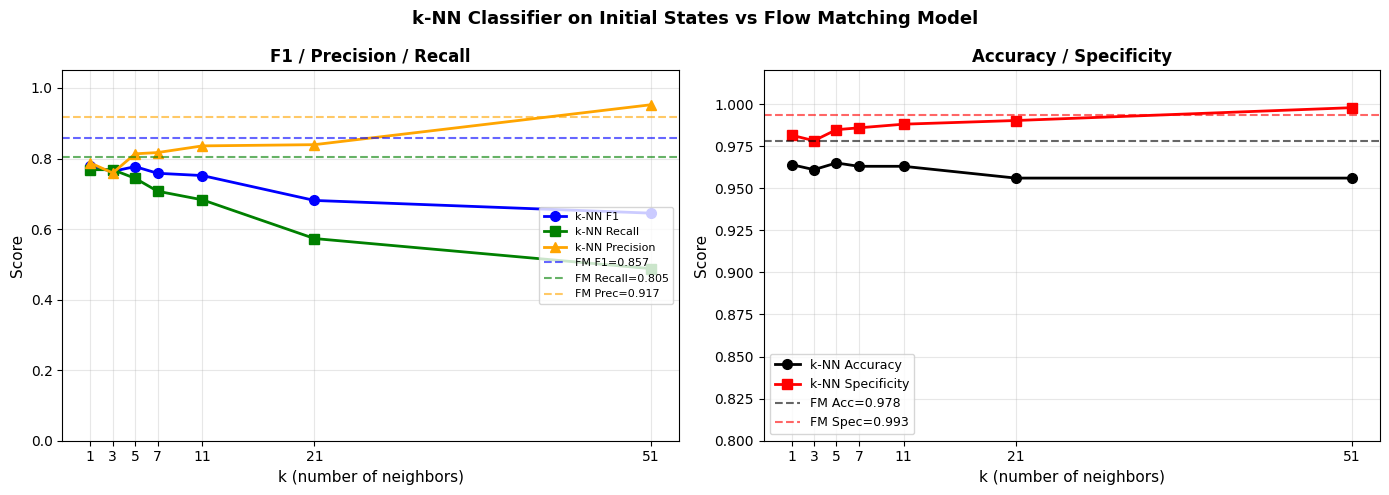

In [53]:
# Plot k-NN performance vs k, with FM baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('k-NN Classifier on Initial States vs Flow Matching Model', fontsize=13, fontweight='bold')

ks = [r['k'] for r in results_knn]

# Plot 1: F1, Recall, Precision vs k
ax = axes[0]
ax.plot(ks, [r['f1'] for r in results_knn], 'b-o', lw=2, ms=7, label='k-NN F1')
ax.plot(ks, [r['recall'] for r in results_knn], 'g-s', lw=2, ms=7, label='k-NN Recall')
ax.plot(ks, [r['precision'] for r in results_knn], 'orange', marker='^', lw=2, ms=7, label='k-NN Precision')

# FM baselines
ax.axhline(y=fm_f1, color='blue', ls='--', lw=1.5, alpha=0.6, label=f'FM F1={fm_f1:.3f}')
ax.axhline(y=fm_recall, color='green', ls='--', lw=1.5, alpha=0.6, label=f'FM Recall={fm_recall:.3f}')
ax.axhline(y=fm_prec, color='orange', ls='--', lw=1.5, alpha=0.6, label=f'FM Prec={fm_prec:.3f}')

ax.set_xlabel('k (number of neighbors)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('F1 / Precision / Recall', fontweight='bold')
ax.legend(fontsize=8, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_xticks(ks)

# Plot 2: Accuracy and Specificity vs k
ax = axes[1]
ax.plot(ks, [r['acc'] for r in results_knn], 'k-o', lw=2, ms=7, label='k-NN Accuracy')
ax.plot(ks, [r['specificity'] for r in results_knn], 'r-s', lw=2, ms=7, label='k-NN Specificity')

ax.axhline(y=fm_acc, color='black', ls='--', lw=1.5, alpha=0.6, label=f'FM Acc={fm_acc:.3f}')
ax.axhline(y=fm_spec, color='red', ls='--', lw=1.5, alpha=0.6, label=f'FM Spec={fm_spec:.3f}')

ax.set_xlabel('k (number of neighbors)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Accuracy / Specificity', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.02)
ax.set_xticks(ks)

plt.tight_layout()
plt.savefig('knn_vs_fm_initial_states.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Investigate: why isn't k-NN perfect if states are "well separated"?
# The separability analysis (Section 13) only looked WITHIN the test set.
# Now check: for misclassified test points, how close is the nearest TRAINING neighbor?

from scipy.spatial.distance import cdist

knn_1 = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_1.fit(train_init_states, train_init_labels)
knn_pred = knn_1.predict(test_init_states)

# Which test success points did 1-NN get wrong?
succ_test_mask = test_init_labels == 1
knn_wrong_succ = succ_test_mask & (knn_pred != test_init_labels)
knn_right_succ = succ_test_mask & (knn_pred == test_init_labels)

print(f"Test success points: {succ_test_mask.sum()}")
print(f"  1-NN correct: {knn_right_succ.sum()}")
print(f"  1-NN wrong:   {knn_wrong_succ.sum()}")

# For each test success point, find nearest training success and failure neighbor
train_succ_mask = train_init_labels == 1
train_fail_mask = train_init_labels == 0

train_succ_states = train_init_states[train_succ_mask]
train_fail_states = train_init_states[train_fail_mask]

print(f"\nTraining set: {train_succ_mask.sum()} success, {train_fail_mask.sum()} failure")

# Distances from test success to nearest train success/failure
test_succ_states = test_init_states[succ_test_mask]

dist_to_train_succ = cdist(test_succ_states, train_succ_states)  # [82, 1520]
dist_to_train_fail = cdist(test_succ_states, train_fail_states)  # [82, 17480]

nn_to_train_succ = dist_to_train_succ.min(axis=1)
nn_to_train_fail = dist_to_train_fail.min(axis=1)

# Which class is closer?
closer_to_fail = nn_to_train_fail < nn_to_train_succ

print(f"\nTest success states - nearest training neighbor:")
print(f"  Nearest train SUCCESS: mean={nn_to_train_succ.mean():.4f}, "
      f"median={np.median(nn_to_train_succ):.4f}, min={nn_to_train_succ.min():.4f}")
print(f"  Nearest train FAILURE: mean={nn_to_train_fail.mean():.4f}, "
      f"median={np.median(nn_to_train_fail):.4f}, min={nn_to_train_fail.min():.4f}")
print(f"  Closer to FAILURE (will misclassify): {closer_to_fail.sum()}/{len(closer_to_fail)}")

# Compare correctly vs incorrectly classified
wrong_mask_local = knn_pred[succ_test_mask] != 1  # within success test subset
right_mask_local = ~wrong_mask_local

print(f"\n  Correctly classified success points:")
print(f"    NN to train success: {nn_to_train_succ[right_mask_local].mean():.4f}")
print(f"    NN to train failure: {nn_to_train_fail[right_mask_local].mean():.4f}")
print(f"    Margin (fail-succ):  {(nn_to_train_fail[right_mask_local] - nn_to_train_succ[right_mask_local]).mean():.4f}")

print(f"\n  Misclassified success points:")
print(f"    NN to train success: {nn_to_train_succ[wrong_mask_local].mean():.4f}")
print(f"    NN to train failure: {nn_to_train_fail[wrong_mask_local].mean():.4f}")
print(f"    Margin (fail-succ):  {(nn_to_train_fail[wrong_mask_local] - nn_to_train_succ[wrong_mask_local]).mean():.4f}")

# Show individual misclassified points
print(f"\nMisclassified success points detail:")
print(f"{'Idx':>4} {'NN→Succ':>9} {'NN→Fail':>9} {'Margin':>9}")
print("-" * 35)
wrong_indices = np.where(wrong_mask_local)[0]
for wi in wrong_indices:
    margin = nn_to_train_fail[wi] - nn_to_train_succ[wi]
    print(f"{wi:4d} {nn_to_train_succ[wi]:9.4f} {nn_to_train_fail[wi]:9.4f} {margin:9.4f}")

Test success points: 82
  1-NN correct: 63
  1-NN wrong:   19

Training set: 1520 success, 17480 failure

Test success states - nearest training neighbor:
  Nearest train SUCCESS: mean=0.4201, median=0.3960, min=0.2300
  Nearest train FAILURE: mean=0.5725, median=0.6070, min=0.2800
  Closer to FAILURE (will misclassify): 19/82

  Correctly classified success points:
    NN to train success: 0.3788
    NN to train failure: 0.6062
    Margin (fail-succ):  0.2274

  Misclassified success points:
    NN to train success: 0.5570
    NN to train failure: 0.4607
    Margin (fail-succ):  -0.0963

Misclassified success points detail:
 Idx   NN→Succ   NN→Fail    Margin
-----------------------------------
   1    0.5367    0.2800   -0.2567
  10    0.4579    0.4579   -0.0000
  14    0.5367    0.4600   -0.0767
  16    0.4579    0.3960   -0.0620
  21    0.8179    0.6070   -0.2110
  25    0.4579    0.2800   -0.1779
  31    0.4579    0.3960   -0.0620
  34    0.6670    0.5962   -0.0709
  38    0.3624  